In [2]:
!pip -q install shap

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
data_path = "/content/drive/MyDrive/Spring Semester 2026/CS 4210/Final Project/parkinsons/parkinsons.data"
df = pd.read_csv(data_path)
print("Data Set Shape: ", df.shape)
df.head()

Data Set Shape:  (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
if "status" in df.columns:
    print(df["status"].value_counts())
else:
    print("No 'status' column found. Please check your dataset.")

Columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Data types:
name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


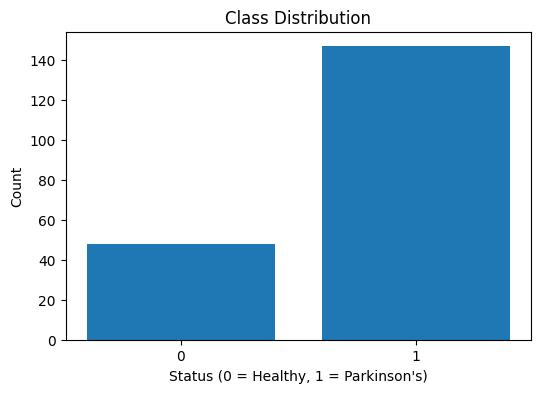

In [8]:
if "status" in df.columns:
    class_counts = df["status"].value_counts().sort_index()

    plt.figure(figsize=(6,4))
    plt.bar(class_counts.index.astype(str), class_counts.values)
    plt.title("Class Distribution")
    plt.xlabel("Status (0 = Healthy, 1 = Parkinson's)")
    plt.ylabel("Count")
    plt.show()

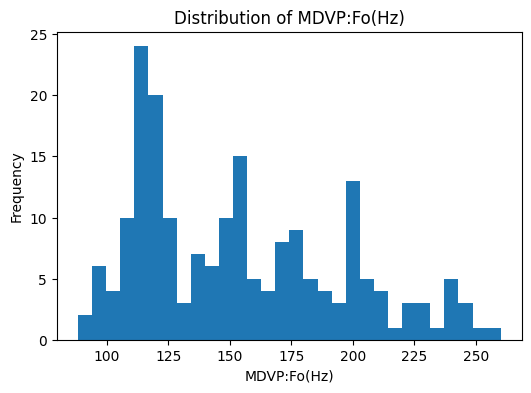

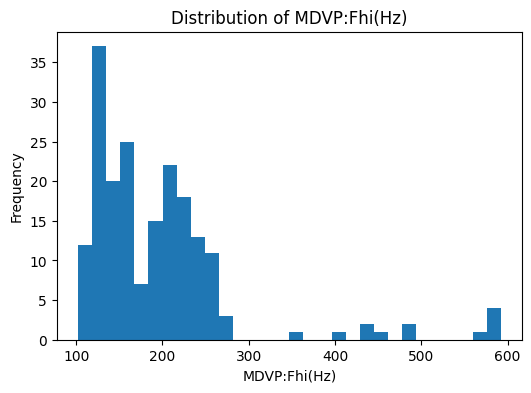

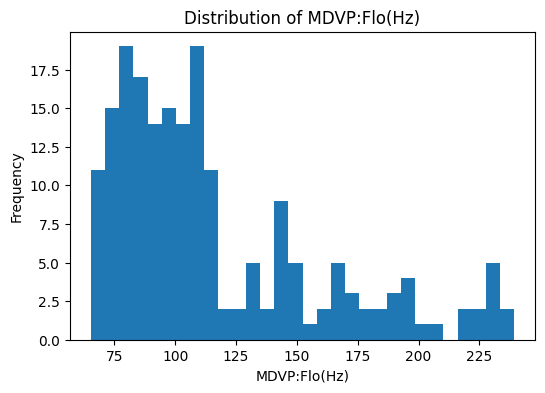

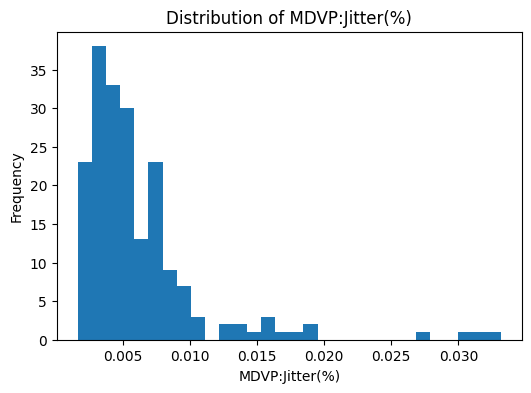

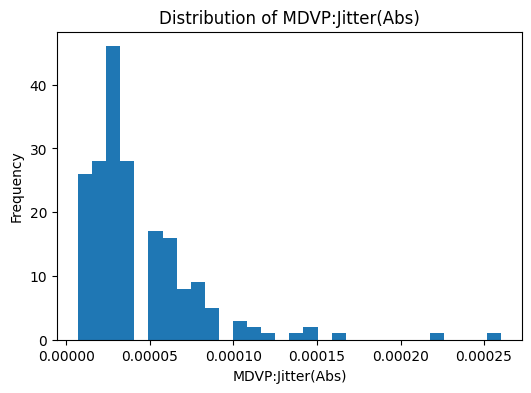

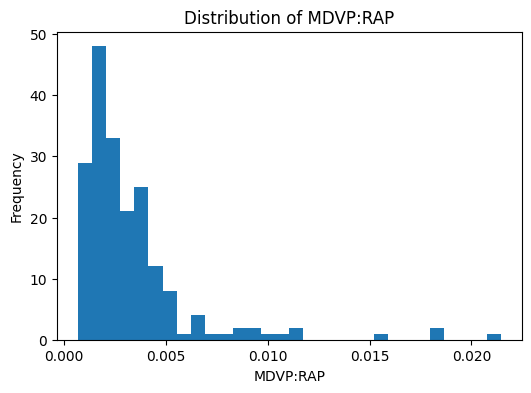

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude target from feature plots if present
plot_cols = [col for col in numeric_cols if col != "status"][:6]

for col in plot_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

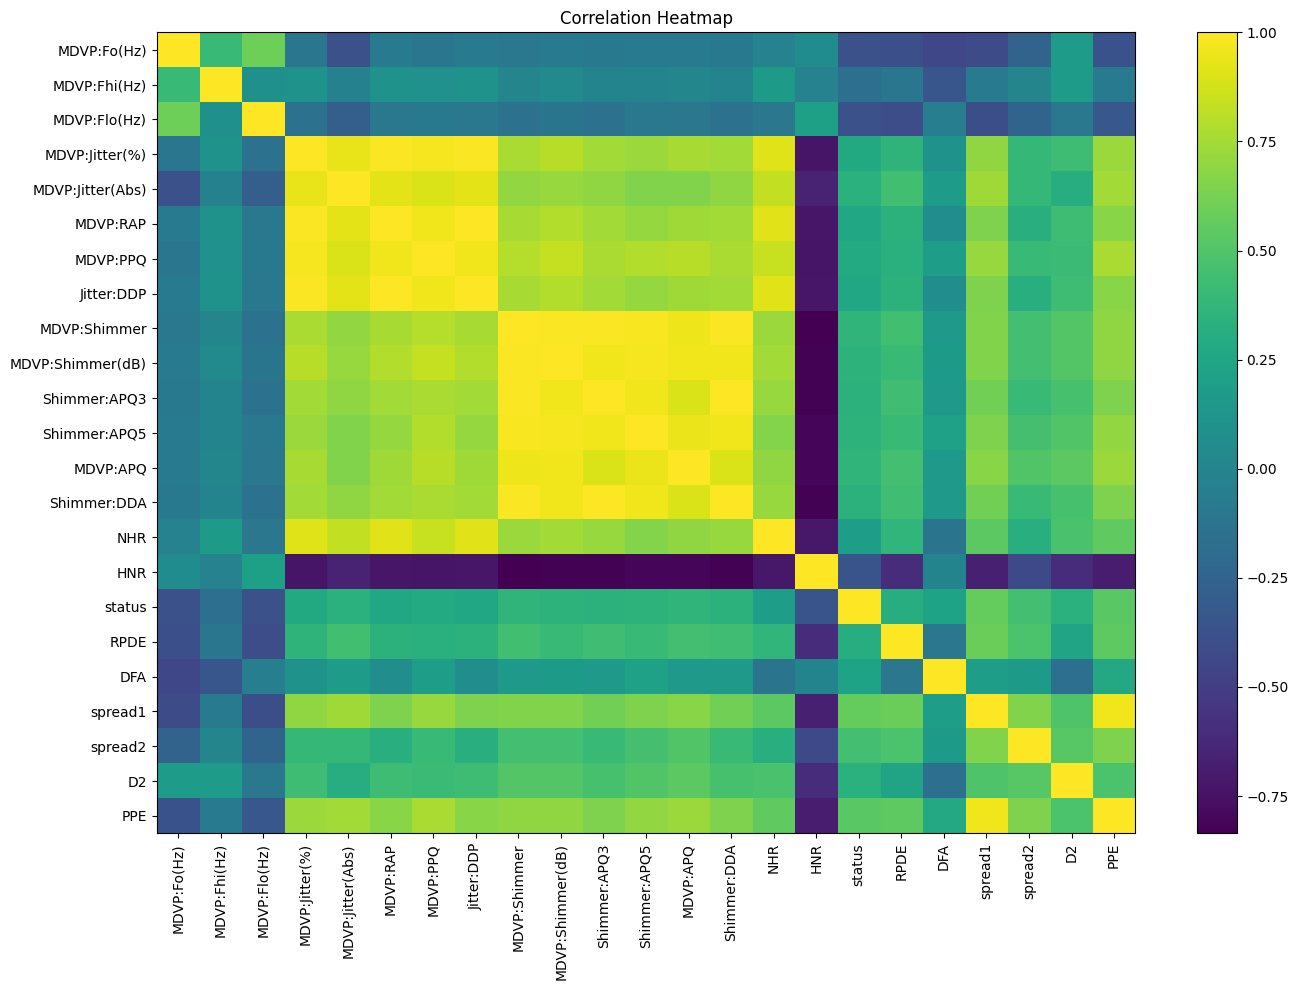

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [11]:
df_model = df.copy()

# Drop identifier column if present
if "name" in df_model.columns:
    df_model = df_model.drop(columns=["name"])

# Ensure target exists
assert "status" in df_model.columns, "Target column 'status' not found."

X = df_model.drop(columns=["status"])
y = df_model["status"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature columns:", X.columns.tolist())

Feature matrix shape: (195, 22)
Target shape: (195,)
Feature columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (156, 22) (156,)
Test set: (39, 22) (39,)


In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
cv_results = []

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)
cv_results_df

,Model,CV F1 Mean,CV F1 Std
2,Random Forest,0.929817,0.031167
1,SVM,0.910910,0.028144
0,Logistic Regression,0.886765,0.024822


In [15]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV F1:", svm_grid.best_score_)

Best SVM Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best SVM CV F1: 0.9273333333333333


In [16]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)

Best RF Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV F1: 0.9333006743341089


In [17]:
best_models = {
    "Best SVM": svm_grid.best_estimator_,
    "Best Random Forest": rf_grid.best_estimator_
}

test_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    test_results.append(result)

test_results_df = pd.DataFrame(test_results).sort_values(by="F1 Score", ascending=False)
test_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Best SVM,0.923077,0.933333,0.965517,0.949153,0.924138
1,Best Random Forest,0.923077,0.933333,0.965517,0.949153,0.962069


In [18]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("Selected Final Model:", best_model_name)

Selected Final Model: Best SVM


In [19]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



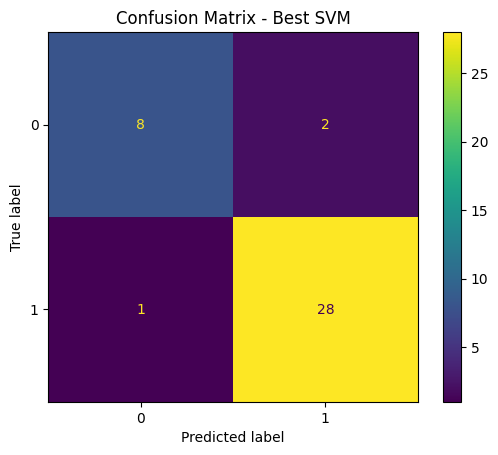

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

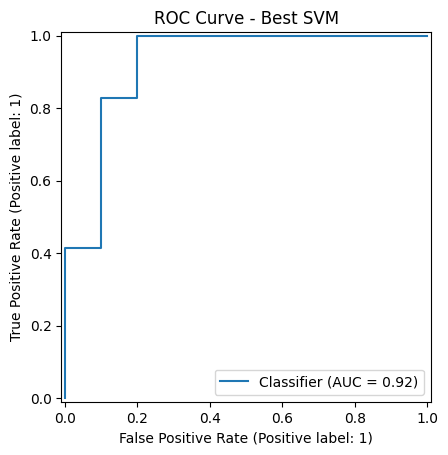

In [21]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

In [22]:
if "Random Forest" in best_model_name:
    rf_model = best_model.named_steps["model"]
    importances = rf_model.feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print(feat_imp.head(15))

    plt.figure(figsize=(10,6))
    plt.barh(feat_imp["Feature"][:15][::-1], feat_imp["Importance"][:15][::-1])
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Best model is not Random Forest. Running coefficient-based or SHAP-based analysis instead.")

Best model is not Random Forest. Running coefficient-based or SHAP-based analysis instead.


             Feature  Coefficient  AbsCoefficient
12          MDVP:APQ     3.681284        3.681284
3     MDVP:Jitter(%)    -2.511911        2.511911
9   MDVP:Shimmer(dB)     2.191920        2.191920
7         Jitter:DDP     1.819076        1.819076
5           MDVP:RAP     1.814602        1.814602
13       Shimmer:DDA    -1.577855        1.577855
10      Shimmer:APQ3    -1.565623        1.565623
11      Shimmer:APQ5    -1.552059        1.552059
4   MDVP:Jitter(Abs)    -1.348477        1.348477
21               PPE     0.999627        0.999627
18           spread1     0.727418        0.727418
8       MDVP:Shimmer     0.721987        0.721987
6           MDVP:PPQ    -0.572572        0.572572
14               NHR     0.391455        0.391455
1       MDVP:Fhi(Hz)    -0.305129        0.305129


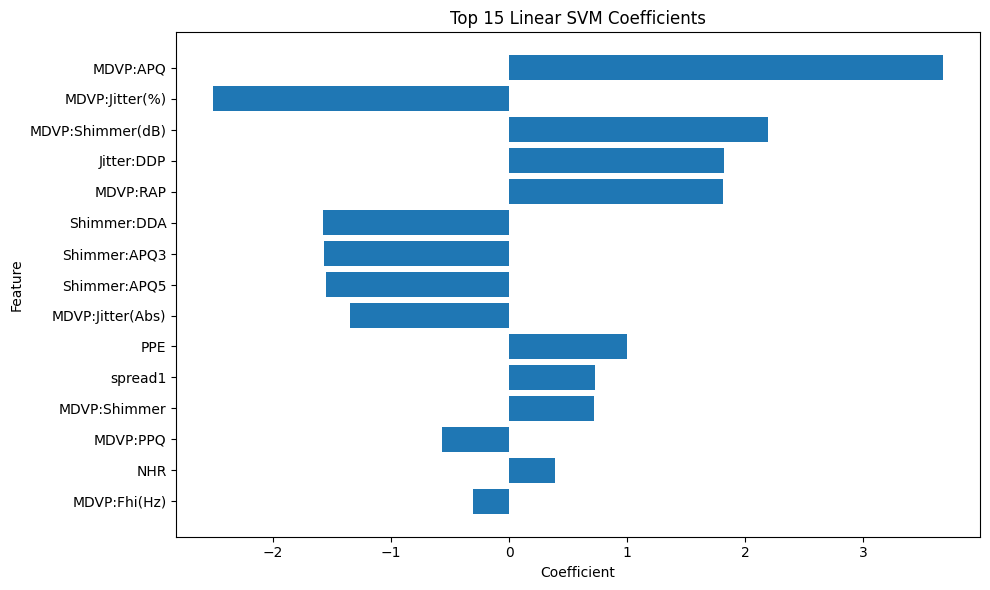

In [23]:
if "SVM" in best_model_name:
    model_step = best_model.named_steps["model"]
    if hasattr(model_step, "kernel") and model_step.kernel == "linear" and hasattr(model_step, "coef_"):
        coefs = model_step.coef_[0]
        coef_df = pd.DataFrame({
            "Feature": X.columns,
            "Coefficient": coefs,
            "AbsCoefficient": np.abs(coefs)
        }).sort_values(by="AbsCoefficient", ascending=False)

        print(coef_df.head(15))

        plt.figure(figsize=(10,6))
        plt.barh(coef_df["Feature"][:15][::-1], coef_df["Coefficient"][:15][::-1])
        plt.title("Top 15 Linear SVM Coefficients")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
    else:
        print("SVM kernel is not linear, so direct coefficient interpretation is unavailable.")

In [24]:
if "Random Forest" in best_model_name:
    X_train_imputed = pd.DataFrame(
        best_model.named_steps["imputer"].transform(X_train),
        columns=X_train.columns
    )
    X_test_imputed = pd.DataFrame(
        best_model.named_steps["imputer"].transform(X_test),
        columns=X_test.columns
    )

    rf_model = best_model.named_steps["model"]
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_imputed)

    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    shap.summary_plot(shap_vals, X_test_imputed)
else:
    print("Skipping SHAP summary plot because final model is not Random Forest.")

Skipping SHAP summary plot because final model is not Random Forest.


In [25]:
joblib.dump(best_model, "parkinsons_best_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Saved:")
print("- parkinsons_best_model.pkl")
print("- feature_columns.pkl")

Saved:
- parkinsons_best_model.pkl
- feature_columns.pkl


In [26]:
loaded_model = joblib.load("parkinsons_best_model.pkl")
loaded_features = joblib.load("feature_columns.pkl")

print("Number of required input features:", len(loaded_features))
print(loaded_features)

Number of required input features: 22
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [27]:
def predict_parkinsons(input_dict, model, feature_columns):
    """
    input_dict: dictionary mapping feature names to values
    model: trained sklearn pipeline
    feature_columns: list of expected feature names
    """
    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=feature_columns)

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    label = "Parkinson's Disease" if prediction == 1 else "Healthy"

    return {
        "prediction_class": int(prediction),
        "prediction_label": label,
        "probability_of_parkinsons": float(probability)
    }

In [28]:
sample_input = X.iloc[0].to_dict()

result = predict_parkinsons(sample_input, loaded_model, loaded_features)
result

{'prediction_class': 1,
 'prediction_label': "Parkinson's Disease",
 'probability_of_parkinsons': 0.8489702067281018}

In [29]:
user_input = {}

print("Enter values for each feature below:")
for feature in loaded_features:
    value = float(input(f"{feature}: "))
    user_input[feature] = value

result = predict_parkinsons(user_input, loaded_model, loaded_features)

print("\nPrediction Result:")
print(result)

Enter values for each feature below:
MDVP:Fo(Hz): 154
MDVP:Fhi(Hz): 152
MDVP:Flo(Hz): 100
MDVP:Jitter(%): 153
MDVP:Jitter(Abs): 90
MDVP:RAP: 39
MDVP:PPQ: 29
Jitter:DDP: 29
MDVP:Shimmer: 10
MDVP:Shimmer(dB): 20
Shimmer:APQ3: 20
Shimmer:APQ5: 2
MDVP:APQ: 1
Shimmer:DDA: 1
NHR: 10
HNR: 10
RPDE: 10
DFA: 10
spread1: 10
spread2: 10
D2: 10
PPE: 10

Prediction Result:
{'prediction_class': 0, 'prediction_label': 'Healthy', 'probability_of_parkinsons': 1.0000000994736041e-07}


In [30]:
joblib.dump(best_model, "parkinsons_best_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']